In [1]:
import sklearn
import imblearn
import numpy as np
import keras_tuner
import tensorflow as tf
from collections import Counter
import matplotlib.pyplot as plt
import Modules.constants as constants
import Modules.ds_loader as ds_loader

SAMPLE_PERCENTAGE = 1.0

DATA_PATH = constants.DATASET
TRAIN_DIR = DATA_PATH / "train"
VAL_DIR = DATA_PATH / "val"
TEST_DIR = DATA_PATH / "test"

X_train, y_train = ds_loader.load_all_data(TRAIN_DIR, SAMPLE_PERCENTAGE)
X_val, y_val = ds_loader.load_all_data(VAL_DIR, SAMPLE_PERCENTAGE)
X_test, y_test = ds_loader.load_all_data(TEST_DIR, SAMPLE_PERCENTAGE)

2025-04-06 23:32:48.708158: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-06 23:32:48.718063: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743975168.728792  111003 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743975168.732308  111003 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743975168.741895  111003 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [5]:
# Function to detect flatlined sequences in features
def is_flatlined(sequence):
    # Check if the sequence is flatlined (all values are the same across all time steps or features)
    return np.all(sequence == sequence[0])

# Remove flatlined sequences
def remove_flatlined_sequences(X, y):
    non_flatlined_indices = [i for i, seq in enumerate(X) if not is_flatlined(seq)]
    return np.array(X)[non_flatlined_indices], np.array(y)[non_flatlined_indices]

# Apply to train, validation, and test sets
X_train, y_train = remove_flatlined_sequences(X_train, y_train)
X_val, y_val = remove_flatlined_sequences(X_val, y_val)
X_test, y_test = remove_flatlined_sequences(X_test, y_test)

print(f"Original train set size: {len(X_train)}, Cleaned train set size: {len(X_train)}")
print(f"Original validation set size: {len(X_val)}, Cleaned validation set size: {len(X_val)}")
print(f"Original test set size: {len(X_test)}, Cleaned test set size: {len(X_test)}")


Original train set size: 8815, Cleaned train set size: 8815
Original validation set size: 2172, Cleaned validation set size: 2172
Original test set size: 947, Cleaned test set size: 947


In [6]:
import numpy as np

# Function to detect flatlined sequences in features
def is_flatlined(sequence):
    # Check if the sequence is flatlined (all values are the same across all time steps or features)
    return np.all(sequence == sequence[0])

# Function to return flatlined sequences
def get_flatlined_sequences(X, y):
    flatlined_indices = [i for i, seq in enumerate(X) if is_flatlined(seq)]
    return np.array(X)[flatlined_indices], np.array(y)[flatlined_indices]

# Apply to train, validation, and test sets
X_train_flatlined, y_train_flatlined = get_flatlined_sequences(X_train, y_train)
X_val_flatlined, y_val_flatlined = get_flatlined_sequences(X_val, y_val)
X_test_flatlined, y_test_flatlined = get_flatlined_sequences(X_test, y_test)

# Print the number of flatlined sequences
print(f"Flatlined train set size: {len(X_train_flatlined)}")
print(f"Flatlined validation set size: {len(X_val_flatlined)}")
print(f"Flatlined test set size: {len(X_test_flatlined)}")


Flatlined train set size: 0
Flatlined validation set size: 0
Flatlined test set size: 0


In [7]:
print("Unique classes in y:", np.unique(y_train))
print("Datatype:", print(X_train.dtype), print(y_train.dtype))
print(X_train.shape, X_test.shape, X_val.shape)
print(y_train.shape, y_test.shape, y_val.shape)
print(f"Min and Max of X_train: {np.min(X_train)}, {np.max(X_train)}")
print(f"Min and Max of X_test: {np.min(X_test)}, {np.max(X_test)}")
print(f"Min and Max of X_val: {np.min(X_val)}, {np.max(X_val)}")
print(f"NaNs in X: {np.isnan(X_train).sum()}")
print(f"Infs in X: {np.isinf(X_train).sum()}")
print(f"Class distribution: {Counter(y_train)}")

Unique classes in y: [0 1 2 3]
float32
int32
Datatype: None None
(8815, 500, 12) (947, 500, 12) (2172, 500, 12)
(8815,) (947,) (2172,)
Min and Max of X_train: 0.0, 1.0000001192092896
Min and Max of X_test: -7.487946510314941, 9.318549156188965
Min and Max of X_val: -8.297019004821777, 8.205255508422852
NaNs in X: 0
Infs in X: 0
Class distribution: Counter({np.int32(2): 3249, np.int32(3): 1897, np.int32(1): 1895, np.int32(0): 1774})


In [8]:
X_train_flat = X_train.reshape((X_train.shape[0],-1))
smote = imblearn.over_sampling.SMOTE(random_state=42)
X_resampled, y_train = smote.fit_resample(X_train_flat, y_train)
X_train = X_resampled.reshape((-1, *X_train.shape[1:]))

print(f"Class distribution: {Counter(y_train)}")

Class distribution: Counter({np.int32(0): 3249, np.int32(1): 3249, np.int32(2): 3249, np.int32(3): 3249})


In [9]:
# 1-D convolutional ResNet model 
# https://pmc.ncbi.nlm.nih.gov/articles/PMC10128986/#sec012
class Resnet(keras_tuner.HyperModel):
    def residual_block(self, inputs, c_units, k_units):

        # C1
        x = tf.keras.layers.Conv1D(filters=c_units, kernel_size=k_units, strides=2, padding='same')(inputs)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)
        
        # C2
        x = tf.keras.layers.Conv1D(filters=c_units, kernel_size=k_units, strides=1, padding='same')(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)

        # SC 1
        s = tf.keras.layers.Conv1D(filters=c_units, kernel_size=1, strides=2, padding='same')(inputs)

        x = tf.keras.layers.Add()([x, s]) 
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.BatchNormalization()(x)
        
        return x

    def build(self, hp):
        # HYPERPARAMS
        k_units = hp.Int('k_units', min_value=3, max_value=9, step=1)

        d_units_1 = hp.Int('d_units_1', min_value=64, max_value=256, step=64)
        d_units_2 = hp.Int('d_units_2', min_value=64, max_value=512, step=64)

        dropout_1 = hp.Float('dropout_1', min_value = 0.3, max_value=0.5, step=0.05)
        dropout_2 = hp.Float('dropout_2', min_value = 0.3, max_value=0.5, step=0.05)
        
        # INPUT LAYER
        inputs = tf.keras.Input(shape=(500,12))
        
        # RESIDUALS
        x = self.residual_block(inputs,32, k_units)
        x = self.residual_block(x, 64, k_units)
        x = self.residual_block(x, 128, k_units)
        x = self.residual_block(x, 256, k_units)

        # CLASSIFIER
        x = tf.keras.layers.MaxPooling1D(pool_size=5, strides=2)(x)
        x = tf.keras.layers.Flatten()(x)
        x = tf.keras.layers.Dense(d_units_1, activation='relu')(x)
        x = tf.keras.layers.Dropout(dropout_1)(x)  

        x = tf.keras.layers.Dense(d_units_2, activation='relu')(x)
        x = tf.keras.layers.Dropout(dropout_2)(x)  

        # OUTPUT
        outputs = tf.keras.layers.Dense(4, activation='softmax')(x)
        
        model = tf.keras.Model(inputs, outputs)
        optimizer = tf.keras.optimizers.Adam(
                        learning_rate=hp.Float('learning_rate', min_value=1e-5, max_value=1e-3),
                        weight_decay=hp.Float('weight_decay', min_value=1e-5, max_value=1e-3)
                    )
        model.compile(
            optimizer=optimizer,
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
        
        
        return model
    
    def fit(self, hp, model, *args, **kwargs):
        return model.fit(
            batch_size= hp.Choice("batch_size", [32,64,100]),
            *args,
            **kwargs,
        ) 

In [10]:
tuner = keras_tuner.BayesianOptimization(
    Resnet(),
    max_trials=160,
    objective='val_accuracy',
    directory="Results/RES_W500_L4_FIXED_02",
    project_name="RES_W500_L4_F_02",
    )

tuner.search_space_summary()

Reloading Tuner from Results/RES_W500_L4_FIXED_02/RES_W500_L4_F_02/tuner0.json
Search space summary
Default search space size: 8
k_units (Int)
{'default': None, 'conditions': [], 'min_value': 3, 'max_value': 9, 'step': 1, 'sampling': 'linear'}
d_units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
d_units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 512, 'step': 64, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.3, 'conditions': [], 'min_value': 0.3, 'max_value': 0.5, 'step': 0.05, 'sampling': 'linear'}
dropout_2 (Float)
{'default': 0.3, 'conditions': [], 'min_value': 0.3, 'max_value': 0.5, 'step': 0.05, 'sampling': 'linear'}
learning_rate (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.001, 'step': None, 'sampling': 'linear'}
weight_decay (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.001, 'step': None, 'sampling': 'line

I0000 00:00:1743975299.678953  111003 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2471 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [11]:
callback_list = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy",mode="max", patience=5, verbose=0),
    #tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
]

tuner.search(
    X_train, y_train, 
    epochs = 200,
    validation_data=(X_val, y_val),
    callbacks=callback_list 
)

Trial 160 Complete [00h 00m 30s]
val_accuracy: 0.37476980686187744

Best val_accuracy So Far: 0.942283570766449
Total elapsed time: 13h 01m 43s


In [12]:
tuner.results_summary()

Results summary
Results in Results/RES_W500_L4_FIXED_02/RES_W500_L4_F_02
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 143 summary
Hyperparameters:
k_units: 3
d_units_1: 256
d_units_2: 64
dropout_1: 0.3
dropout_2: 0.5
learning_rate: 0.001
weight_decay: 1e-05
batch_size: 32
Score: 0.942283570766449

Trial 152 summary
Hyperparameters:
k_units: 3
d_units_1: 64
d_units_2: 64
dropout_1: 0.3
dropout_2: 0.5
learning_rate: 0.001
weight_decay: 0.0007824072427531387
batch_size: 32
Score: 0.9396869540214539

Trial 157 summary
Hyperparameters:
k_units: 3
d_units_1: 128
d_units_2: 256
dropout_1: 0.4
dropout_2: 0.5
learning_rate: 0.001
weight_decay: 0.0007057820028546128
batch_size: 32
Score: 0.9373849034309387

Trial 154 summary
Hyperparameters:
k_units: 3
d_units_1: 192
d_units_2: 192
dropout_1: 0.4
dropout_2: 0.4
learning_rate: 0.001
weight_decay: 0.001
batch_size: 32
Score: 0.9355432987213135

Trial 066 summary
Hyperparameters:
k_units: 3
d_units_1: 256
d_units_2:

In [13]:
models = tuner.get_best_models(num_models=1)
best_model = models[0]
best_model.summary()
best_model.save("Results/RES_W500_L4_FIXED_02/RES_W500_L4_FIXED_02.keras") 

/home/capitan/.venv/tenv/lib64/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 110 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 500, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 250, 32)   │      1,184 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 250, 32)   │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 250, 32)   │        128 │ re_lu[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 250, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 250, 32)   │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 32)   │        128 │ re_lu_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 250, 32)   │        416 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 250, 32)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 250, 32)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 32)   │        128 │ re_lu_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 125, 64)   │      6,208 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 125, 64)   │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 64)   │        256 │ re_lu_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 125, 64)   │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 125, 64)   │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 64)   │        256 │ re_lu_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 125, 64)   │      2,112 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 125, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 125, 64)   │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 64)   │        256 │ re_lu_5[0][0]   

 Total params: 1,376,356 (5.25 MB)

 Trainable params: 1,373,476 (5.24 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [14]:
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, batch_size=16)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9220 - loss: 0.6669
Test Loss: 0.4135964512825012
Test Accuracy: 0.9514255523681641


In [15]:
y_pred = best_model.predict(X_test)

if y_pred.shape[1] == 1:  
    y_pred_binary = (y_pred > 0.5).astype(int)
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred)  
else:
    y_pred_binary = np.argmax(y_pred, axis=1)  
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred, multi_class='ovr')

print("Classification Report (Test Data):")
print(sklearn.metrics.classification_report(y_test, y_pred_binary))
print(f"AUC: {auc}")

y_train_pred = best_model.predict(X_train)
y_train_pred = np.argmax(y_train_pred, axis=1)

print("Classification Report (Train Data):")
print(sklearn.metrics.classification_report(y_train, y_train_pred))

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.95      0.87      0.91       181
           1       0.89      0.94      0.91       204
           2       0.99      0.99      0.99       357
           3       0.96      0.97      0.96       205

    accuracy                           0.95       947
   macro avg       0.95      0.94      0.94       947
weighted avg       0.95      0.95      0.95       947

AUC: 0.9915041889965859
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Classification Report (Train Data):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3249
           1       0.99      0.99      0.99      3249
           2       1.00      1.00      1.00      3249
           3       1.00      0.99      0.99      3249

    accuracy                           0.99     12996
   macro avg       0.99      0.99      0.99     12996
weighted 

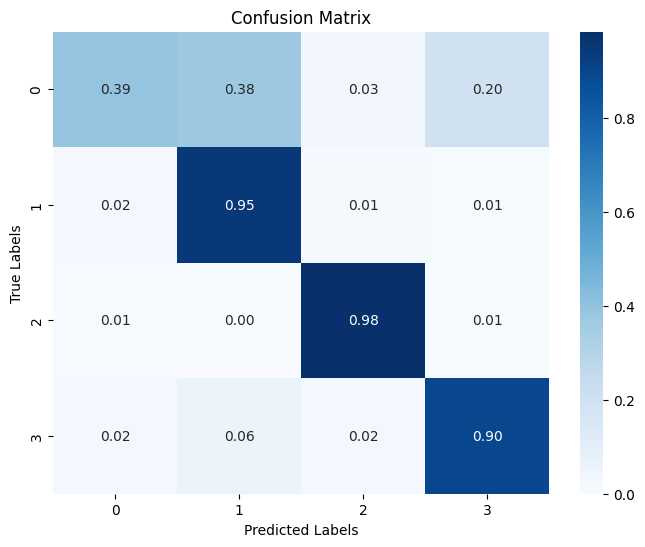

In [27]:
import seaborn as sns
y_pred_class = np.argmax(y_pred, axis=1)  
cm = sklearn.metrics.confusion_matrix(y_test, y_pred_class, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [16]:
best_hps = tuner.get_best_hyperparameters(num_trials=54)[1] 
print(best_hps.values)

{'k_units': 3, 'd_units_1': 64, 'd_units_2': 64, 'dropout_1': 0.3, 'dropout_2': 0.5, 'learning_rate': np.float64(0.001), 'weight_decay': np.float64(0.0007824072427531387), 'batch_size': 32}


In [21]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0] 
modified_hps = best_hps.copy()

#modified_hps.values['c_units_1'] = 64

best_model = Resnet().build(best_hps)
#best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, weight_decay=8e-05),
#                   loss='sparse_categorical_crossentropy',
#                   metrics=['accuracy']) 
history = best_model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val),
    epochs=50,
    callbacks=callback_list
    )


Epoch 1/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.2948 - loss: 1.7974 - val_accuracy: 0.5773 - val_loss: 1.0565
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5155 - loss: 1.0483 - val_accuracy: 0.7343 - val_loss: 0.9332
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7489 - loss: 0.6226 - val_accuracy: 0.7781 - val_loss: 0.6911
Epoch 4/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8393 - loss: 0.4486 - val_accuracy: 0.8504 - val_loss: 0.5002
Epoch 5/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9031 - loss: 0.2929 - val_accuracy: 0.8610 - val_loss: 0.4655
Epoch 6/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9146 - loss: 0.2849 - val_accuracy: 0.8361 - val_loss: 0.5293
Epoch 7/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9435 - loss: 0.1962 - val_accuracy: 0.8987 - val_loss: 0.3869
Epoch 8/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9467 - loss: 0.1766 - val_accuracy: 

In [30]:
kfold = sklearn.model_selection.KFold(n_splits=10, shuffle=True, random_state=42)

fold_accuracies = []
fold_histories = []

best_accuracy = 0.0
best_model = None  # To store the best-performing model

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    print(f"\n--- Fold {fold+1} ---")

    # Split data
    X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_tr, y_val_fold = y_train[train_idx], y_train[val_idx]

    # Build and compile model
    model = Resnet().build(best_hps)

    # Train model
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50,
        callbacks=callback_list,
        verbose=1
    )

    # Evaluate on validation set
    val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold+1} Validation Accuracy: {val_accuracy:.4f}")
    fold_accuracies.append(val_accuracy)
    fold_histories.append(history)

    # Save the best model based on validation accuracy
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_model = model
        model.save('best_cv_model.h5')  # You can change the filename
        print(f"✔️ Saved best model from Fold {fold+1} with Accuracy: {val_accuracy:.4f}")



--- Fold 1 ---
Epoch 1/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.2624 - loss: 1.9420 - val_accuracy: 0.2346 - val_loss: 1.3875
Epoch 2/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2980 - loss: 1.3484 - val_accuracy: 0.5569 - val_loss: 0.9423
Epoch 3/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5452 - loss: 0.9624 - val_accuracy: 0.7523 - val_loss: 0.5772
Epoch 4/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7292 - loss: 0.6546 - val_accuracy: 0.8231 - val_loss: 0.4292
Epoch 5/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8141 - loss: 0.5035 - val_accuracy: 0.8723 - val_loss: 0.3740
Epoch 6/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8809 - loss: 0.3674 - val_accuracy: 0.8785 - val_loss: 0.3465
Epoch 7/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9116 - loss: 0.2799 - val_accuracy: 0.9323 - val_loss: 0.2152
Epoch 8/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9332 - loss: 0.2070 

Fold 1 Validation Accuracy: 0.9631
✔️ Saved best model from Fold 1 with Accuracy: 0.9631

--- Fold 2 ---
Epoch 1/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.2831 - loss: 1.8758 - val_accuracy: 0.2885 - val_loss: 1.3586
Epoch 2/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4622 - loss: 1.1140 - val_accuracy: 0.7577 - val_loss: 0.6841
Epoch 3/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7317 - loss: 0.6718 - val_accuracy: 0.8069 - val_loss: 0.4805
Epoch 4/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8011 - loss: 0.5299 - val_accuracy: 0.8469 - val_loss: 0.4024
Epoch 5/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8599 - loss: 0.4030 - val_accuracy: 0.9085 - val_loss: 0.2539
Epoch 6/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8983 - loss: 0.3129 - val_accuracy: 0.9238 - val_loss: 0.2074
Epoch 7/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9302 - loss: 0.2155 - val_accuracy: 0.9300 - val_loss: 0.18

Fold 5 Validation Accuracy: 0.9685
✔️ Saved best model from Fold 5 with Accuracy: 0.9685

--- Fold 6 ---
Epoch 1/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.2975 - loss: 1.7159 - val_accuracy: 0.3085 - val_loss: 1.6248
Epoch 2/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5718 - loss: 0.9659 - val_accuracy: 0.8008 - val_loss: 0.5068
Epoch 3/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7623 - loss: 0.6091 - val_accuracy: 0.8531 - val_loss: 0.4395
Epoch 4/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8498 - loss: 0.4246 - val_accuracy: 0.8962 - val_loss: 0.3590
Epoch 5/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8954 - loss: 0.3185 - val_accuracy: 0.9115 - val_loss: 0.2359
Epoch 6/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9194 - loss: 0.2566 - val_accuracy: 0.9069 - val_loss: 0.2682
Epoch 7/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9299 - loss: 0.2108 - val_accuracy: 0.9177 - val_loss: 0.21

In [31]:
print("\nCross-validation accuracies:", fold_accuracies)
print("Average CV accuracy:", np.mean(fold_accuracies))



Cross-validation accuracies: [0.9630769491195679, 0.9623076915740967, 0.9523077011108398, 0.9599999785423279, 0.9684615135192871, 0.9238461256027222, 0.9522709846496582, 0.9522709846496582, 0.960739016532898, 0.9391840100288391]
Average CV accuracy: 0.9534464955329895


In [32]:
best_model = tf.keras.models.load_model('best_cv_model.h5')


In [34]:
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, batch_size=16)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8811 - loss: 0.6228
Test Loss: 0.3729618191719055
Test Accuracy: 0.9250264167785645


In [35]:
y_pred = best_model.predict(X_test)

if y_pred.shape[1] == 1:  
    y_pred_binary = (y_pred > 0.5).astype(int)
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred)  
else:
    y_pred_binary = np.argmax(y_pred, axis=1)  
    auc = sklearn.metrics.roc_auc_score(y_test, y_pred, multi_class='ovr')

print("Classification Report (Test Data):")
print(sklearn.metrics.classification_report(y_test, y_pred_binary))
print(f"AUC: {auc}")

y_train_pred = best_model.predict(X_train)
y_train_pred = np.argmax(y_train_pred, axis=1)

print("Classification Report (Train Data):")
print(sklearn.metrics.classification_report(y_train, y_train_pred))


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step 
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       181
           1       0.87      0.90      0.88       204
           2       0.96      0.99      0.98       357
           3       0.96      0.93      0.95       205

    accuracy                           0.93       947
   macro avg       0.92      0.91      0.91       947
weighted avg       0.92      0.93      0.92       947

AUC: 0.9866874059471324
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report (Train Data):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3249
           1       0.99      0.99      0.99      3249
           2       0.99      1.00      1.00      3249
           3       1.00      0.99      0.99      3249

    accuracy                           0.99     12996
   macro avg       0.99      0.99      0.99     12996
weighted

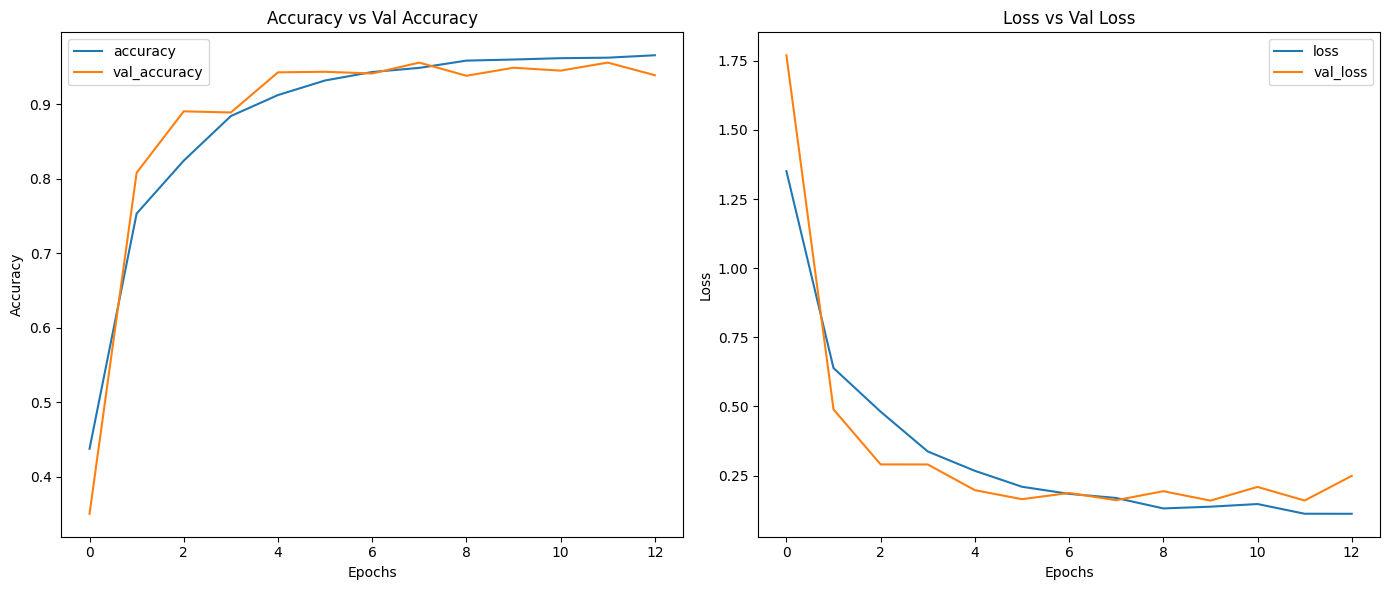

In [36]:

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(history.history['accuracy'], label='accuracy')
ax[0].plot(history.history['val_accuracy'], label='val_accuracy')
ax[0].set_title('Accuracy vs Val Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='loss')
ax[1].plot(history.history['val_loss'], label='val_loss')
ax[1].set_title('Loss vs Val Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()